### __Outline__

  - [Introduction](#Introduction)
  - [1. Variable types and summary statistics](#1.-Variable-types-and-summary-statistics)
  - [2. Dummy variable encoding](#2.-Dummy-variable-encoding)
  - [3. Correlations and model structure](#3.-Correlations-and-model-structure)
  - [4. Variable selection by correlation and significance](#4.-Variable-selection-by-correlation-and-significance)
  - [5. Variable selection by variance thresholds](#5.-Variable-selection-by-variance-thresholds)
  - [6. Train and compare models on the reduced datasets](#6.-Train-and-compare-models-on-the-reduced-datasets)
  - [Conclusion](#Conclusion)

### __Introduction__

**Variables** are the basic building blocks of datasets. The **quality of the variables** present within your dataset has a direct impact on the intuition and overall outcome of your machine learning model.

Although similar machine models may be implemented within the same industry, this does not mean they necessarily require the same features. **Variable selection** and an in-depth knowledge of the domain you're building your model in remain essential when developing a predictive model.

The purpose of regression is essentially to build associations between multiple variables.

> Variable selection involves the **elimination of some input variables** which may, in turn, reduce the computational cost of modelling and, in some cases, improve the performance of the model.

Within this notebook, we will investigate appropriate ways of performing this model selection.

The model is structured around the belief that one of the variables in our dataset is a **dependent variable (DV)**, that is explained or predicted in some way by the other **independent variables (IVs)**. In this sense we work with:

- **Input variables** – referred to as the independent variables (IVs) and are used to explain or predict the target variable.

- **Target variable** – referred to as the dependent variable (DV) and is the target variable we want to predict.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from styleplot import style_plot

We will be using the `personal_loans` dataset which contains data of **bank customers**. The data include basic information of each customer as well as whether the customer took out a loan and the size of that loan.

The basic information consists of:
* **Age** – the customer's age in years.
* **Experience** – working experience in years.
* **Income** – annual income expressed in multiples of 1000.
* **Family** – members in the family, including the customer self.
* **CCAvg** – average monthly spend on credit card.
* **Education** – undergrad/postgrad/professional.
* **Mortgage** – amount expressed in multiples of 1000.
* **Securities Account** – whether the customer has a securities account.
* **CD Account** – whether the customer has a cash deposit account.
* **Online** – whether the customer is using online banking.
* **Gender** – male/female.
* **Area** – geographic area where the customer lives.
* **Personal Loan** – whether the person took out a personal loan.
* **Loan Size** – amount expressed in multiples of  1000.

We will **load our data** as a Pandas DataFrame:

In [3]:
#df = pd.read_csv("https://cdn.alx-ai-tools.com/marimo/v2/data/bootcamps/Personal_Loans.csv")
#df.to_csv("personal_loans.csv", index = False)

In [4]:
loans = pd.read_csv("personal_loans.csv")
loans.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,Gender,Area,Personal Loan,Loan Size
0,26,2,60,2,3.0,Undergrad,132,0,0,0,Male,Alameda,1,15
1,26,0,83,3,3.9,Postgrad,0,0,0,1,Female,Ventura,1,30
2,26,0,129,3,0.7,Postgrad,0,0,0,0,Male,Los Angeles,1,33
3,26,0,132,3,6.5,Professional,0,0,0,0,Female,Orange,1,40
4,26,2,132,2,2.4,Professional,0,0,0,0,Male,Alameda,1,35


### __Pre-processing__

With our data loaded, we now consider doing some preliminary data preprocessing.

Some of the **columns have white space** that we want to replace with an underscore (to avoid using the column names as variable names later on).

In [5]:
loans.columns = [
    col.strip().replace(" ", "_").lower()
    for col in loans.columns
]

loans.head(3)

,age,experience,income,family,ccavg,education,mortgage,securities_account,cd_account,online,gender,area,personal_loan,loan_size
0,26,2,60,2,3.0,Undergrad,132,0,0,0,Male,Alameda,1,15
1,26,0,83,3,3.9,Postgrad,0,0,0,1,Female,Ventura,1,30
2,26,0,129,3,0.7,Postgrad,0,0,0,0,Male,Los Angeles,1,33


If we want to build some relationship between variables that are likely to indicate the loan amount once someone has taken a loan, we really only want to **consider customers who actually took a personal loan** to build this relationship:

### 1. __Variable types and summary statistics__

In this section, we will explore the data types and the summary statistics of our variables.

Variables have **different levels** of inherent statistical and model building information.

In [6]:
from IPython.display import Image
from IPython.core.display import HTML 
Image(url='https://raw.githubusercontent.com/Explore-AI/Pictures/master/Variable_data_types.jpg')

__The most important thing__

`.info()` is especially useful for checking missing values and data types.

For example:

In [7]:
print(loans.info())

<class 'pandas.DataFrame'>
RangeIndex: 4846 entries, 0 to 4845
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 4846 non-null   int64  
 1   experience          4846 non-null   int64  
 2   income              4846 non-null   int64  
 3   family              4846 non-null   int64  
 4   ccavg               4846 non-null   float64
 5   education           4846 non-null   str    
 6   mortgage            4846 non-null   int64  
 7   securities_account  4846 non-null   int64  
 8   cd_account          4846 non-null   int64  
 9   online              4846 non-null   int64  
 10  gender              4846 non-null   str    
 11  area                4846 non-null   str    
 12  personal_loan       4846 non-null   int64  
 13  loan_size           4846 non-null   int64  
dtypes: float64(1), int64(10), str(3)
memory usage: 643.9 KB
None


__Summary Statistics__

In [8]:
loans.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4846.0,45.388981,11.423346,23.0,35.0,45.0,55.0,67.0
experience,4846.0,20.169212,11.363324,0.0,10.0,20.0,30.0,43.0
income,4846.0,73.995047,46.017608,8.0,39.0,64.0,98.0,224.0
family,4846.0,2.395378,1.143967,1.0,1.0,2.0,3.0,4.0
ccavg,4846.0,1.942984,1.745590,0.0,0.7,1.6,2.5,10.0
mortgage,4846.0,56.936236,102.061477,0.0,0.0,0.0,101.0,635.0
securities_account,4846.0,0.104003,0.305296,0.0,0.0,0.0,0.0,1.0
cd_account,4846.0,0.060050,0.237603,0.0,0.0,0.0,0.0,1.0
online,4846.0,0.598019,0.490349,0.0,0.0,1.0,1.0,1.0
personal_loan,4846.0,0.097194,0.296252,0.0,0.0,0.0,0.0,1.0


### 2. __Dummy variable encoding__

As observed in the above table, we get little information from the summary statistics of our numerical categorical data (`Online`, `CD_Account`, `Securities_Account`).

More importantly, **all input data for regression model** building purposes **need to be numerical**.

We, therefore, have to **transform the text data** (found within columns such as `Education`, `Gender`, and `Area`) **into numbers** before we can train our machine learning model.

To facilitate this transformation from textual-categorical data to numerical equivalents, we **use a Pandas method** called `get_dummies`.

`get_dummies` will transform all the categorical text data into numbers by adding a **column for each distinct category**. The new column has:
- `1` for observations that **were** in this category.
- `0` for observations that **were** not in this category.

For example, the DataFrame:

| Dog Age | Breed      |
|---------|------------|
| 15      | "Bulldog"  |
| 12      | "Labrador" |
| 10      | "Labrador" |
| 22      | "Beagle"   |
| 9       | "Labrador" |

After `pd.dummies` becomes:

| Dog Age | Breed_Labrador | Breed_Bulldog | Breed_Beagle |
|---------|----------------|---------------|--------------|
| 15      | 1              | 0             | 0            |
| 12      | 0              | 1             | 0            |
| 10      | 1              | 0             | 0            |
| 22      | 0              | 0             | 1            |
| 9       | 1              | 0             | 0            |

In general, this is a process known as [Dummy Variable Encoding](https://en.wikiversity.org/wiki/Dummy_variable_(statistics)) and is an important step in preprocessing data for regression analysis.

Let's see what this process looks like with our personal loans dataset:

In [9]:
# 1. Create dummy variables
df = pd.get_dummies(loans, dtype=int)

# 2. Replace spaces with underscores
df.columns = [
    col.replace(' ', '_').lower()
    for col in df.columns
]

# 3, Display the first two rows
df.head(2)

,age,experience,income,family,ccavg,mortgage,securities_account,cd_account,online,personal_loan,...,area_santa_cruz,area_shasta,area_siskiyou,area_solano,area_sonoma,area_stanislaus,area_trinity,area_tuolumne,area_ventura,area_yolo
0,26,2,60,2,3.0,132,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,26,0,83,3,3.9,0,0,0,1,1,...,0,0,0,0,0,0,0,0,1,0


### 3. __Correlations and model structure__

Using the dummy variable DataFrame, we can build a model that predicts `loan_size` (our dependent variable) as a function of **53 different independent variables**.

Before we do this, however, let's **reorder columns** so that our dependent variable is the last column of the DataFrame:

In [12]:
column_titles = [col for col in df.columns if col != 'loan_size'] + ['loan_size']

df = df.reindex(columns=column_titles)

In [13]:
df.head()

,age,experience,income,family,ccavg,mortgage,securities_account,cd_account,online,personal_loan,...,area_shasta,area_siskiyou,area_solano,area_sonoma,area_stanislaus,area_trinity,area_tuolumne,area_ventura,area_yolo,loan_size
0,26,2,60,2,3.0,132,0,0,0,1,...,0,0,0,0,0,0,0,0,0,15
1,26,0,83,3,3.9,0,0,0,1,1,...,0,0,0,0,0,0,0,1,0,30
2,26,0,129,3,0.7,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,33
3,26,0,132,3,6.5,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,40
4,26,2,132,2,2.4,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,35


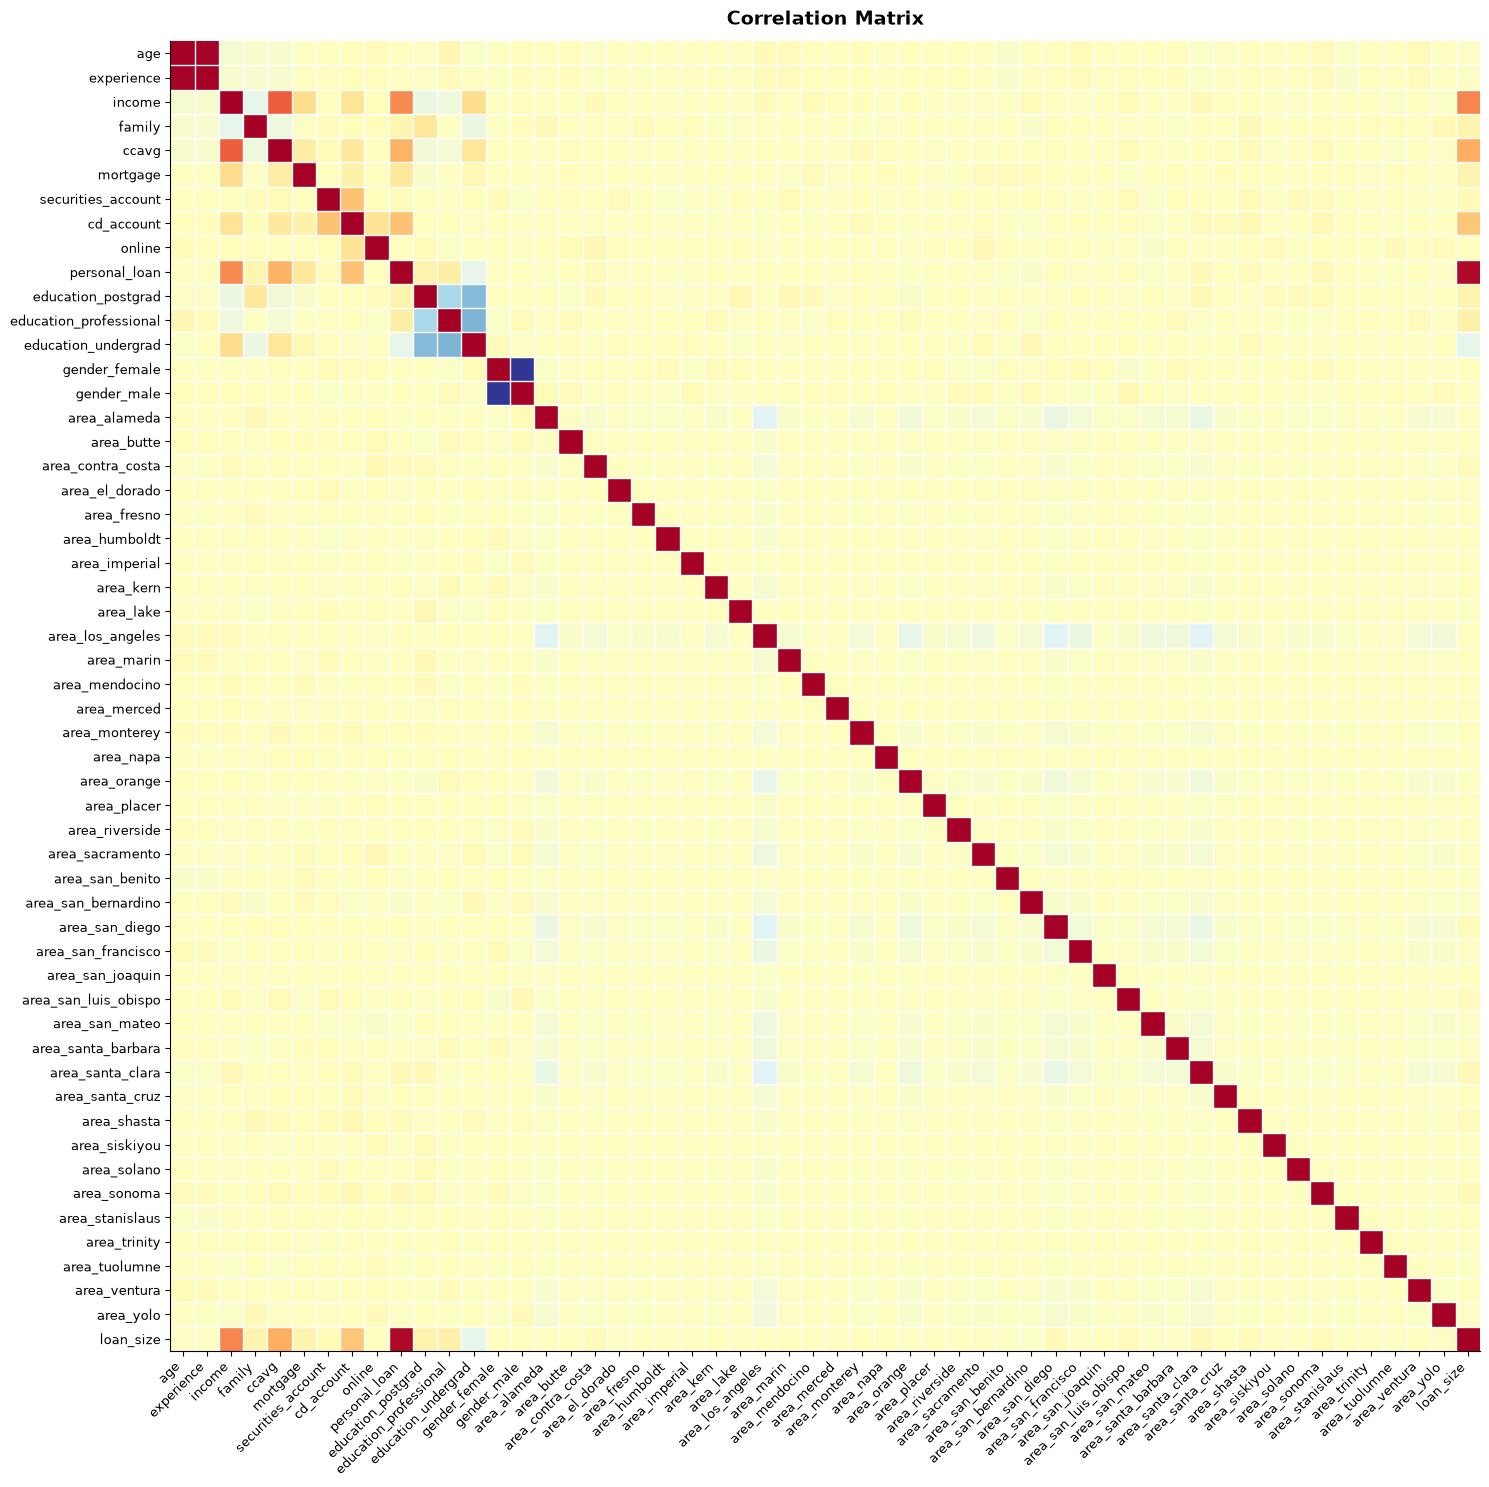

In [20]:
from statsmodels.graphics.correlation import plot_corr

corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(15, 15))

plot_corr(
    corr_matrix,
    xnames=corr_matrix.columns,
    ax=ax
)

style_plot(
    ax,
    title="Correlation Matrix",
    grid=False
)

plt.tight_layout()
plt.show()

We can see from the correlations that it's not the best idea to keep all of the dummy variables.

If we use all of these variables, we're effectively working with **superfluous or redundant information**.

Our model will also have **collinearity issues**:

- `Gender_Male` and `Gender_Female` are perfectly negatively correlated.

This will likely be a problem when we build a model – let's check what an OLS model summary says.

### __Fitting the model using statsmodels.OLS__

#### __Generating the regression string__

We will be importing the `statsmodels` library which has a rich set of statistical tools to help us.

Those of you familiar with the R language will know that fitting a machine learning model requires a sort of string of the form:

`y ~ X`

which reads: **"Regress y on X"**.

`statsmodels` works in a similar way, so we need to generate an appropriate string to feed to the method when we wish to fit the model.

In [24]:
from statsmodels.formula.api import ols

In [22]:
dfm = df.copy()
y = 'loan_size'
X = [col for col in dfm.columns if col != y]

formula = y + ' ~ ' + ' + '.join(X)

print(f"Formula:\n\t{formula}")

Formula:
	loan_size ~ age + experience + income + family + ccavg + mortgage + securities_account + cd_account + online + personal_loan + education_postgrad + education_professional + education_undergrad + gender_female + gender_male + area_alameda + area_butte + area_contra_costa + area_el_dorado + area_fresno + area_humboldt + area_imperial + area_kern + area_lake + area_los_angeles + area_marin + area_mendocino + area_merced + area_monterey + area_napa + area_orange + area_placer + area_riverside + area_sacramento + area_san_benito + area_san_bernardino + area_san_diego + area_san_francisco + area_san_joaquin + area_san_luis_obispo + area_san_mateo + area_santa_barbara + area_santa_clara + area_santa_cruz + area_shasta + area_siskiyou + area_solano + area_sonoma + area_stanislaus + area_trinity + area_tuolumne + area_ventura + area_yolo


In [23]:
model = ols(formula=formula, data=dfm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              loan_size   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     1154.
Date:                Mon, 10 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:51:42   Log-Likelihood:                -11958.
No. Observations:                4846   AIC:                         2.402e+04
Df Residuals:                    4795   BIC:                         2.435e+04
Df Model:                          50                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

In [25]:
# Target variable
target = "loan_size"

# Calculate correlation with the target
correlations = (
    df.corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

# Keep important features
important_features = correlations[abs(correlations) >= 0.15].index.tolist()

print("Important features:")
print(important_features)

Important features:
['personal_loan', 'income', 'ccavg', 'cd_account', 'education_undergrad']


In [26]:
# Features and target
X = df[important_features]
y = df[target]

# Fit model
model = LinearRegression()
model.fit(X, y)

# Results
coefficients = pd.DataFrame({
    "feature": important_features,
    "coefficient": model.coef_
})

print("Selected features:")
print(important_features)

print("\nR²:", model.score(X, y))

coefficients

Selected features:
['personal_loan', 'income', 'ccavg', 'cd_account', 'education_undergrad']

R²: 0.9161807517790418


,feature,coefficient
0,personal_loan,32.080356
1,income,0.005789
2,ccavg,0.272766
3,cd_account,-0.120610
4,education_undergrad,-0.528289
